In [ ]:
# ===========================================================================
#Install dependencies (same pinned versions as training)
# ===========================================================================
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "torch", "torchvision", "torchaudio",
                "--index-url", "https://download.pytorch.org/whl/cu124"],
               check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers==4.48.1",
                "accelerate==1.3.0",
                "peft==0.14.0",
                "bitsandbytes>=0.43.0",   # env parity only — not used for quant
                "datasets>=2.18.0",
                "scikit-learn",
                "pandas",
                "numpy",
                "sentencepiece",
                "matplotlib",
                "seaborn"],
               check=True)

print("\u2705  Packages ready.")

✅  Packages ready.


In [ ]:
# ===========================================================================
# Mount Google Drive & HuggingFace login
# ===========================================================================
from google.colab import drive
drive.mount("/content/drive")

from huggingface_hub import login
HF_TOKEN = "hf_O***************************"   
login(HF_TOKEN)
print("\u2705  Drive mounted & HF login done.")

Mounted at /content/drive
✅  Drive mounted & HF login done.


In [ ]:
# ===========================================================================
# CELL 3 – Imports
# ===========================================================================
import os, json, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: No BitsAndBytesConfig needed — full bfloat16 LoRA evaluation
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

print("\u2705  Imports done.")
print("    GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")
print("    VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

✅  Imports done.
    GPU: NVIDIA A100-SXM4-80GB
    VRAM: 85.1 GB


In [ ]:
# ===========================================================================
# Paths  (must match phi4_legal_lora_v2.ipynb exactly)
# ===========================================================================
BASE_MODEL_ID   = "microsoft/Phi-4-mini-instruct"

PROJECT_DIR     = "/content/drive/MyDrive/phi4_thesis_LoRA"
LORA_DIR        = os.path.join(PROJECT_DIR, "lora_model")
SPLITS_DIR      = os.path.join(PROJECT_DIR, "splits")
METRICS_DIR     = os.path.join(PROJECT_DIR, "metrics")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "predictions")

for folder in [METRICS_DIR, PREDICTIONS_DIR]:
    os.makedirs(folder, exist_ok=True)

# Load the label list that was saved alongside the adapter during training
labels_path = os.path.join(LORA_DIR, "labels.json")
if not os.path.exists(labels_path):              # fallback to splits dir
    labels_path = os.path.join(SPLITS_DIR, "labels.json")

with open(labels_path) as f:
    LABELS = json.load(f)

LABELS_LOWER = [l.lower().strip() for l in LABELS]

print("LORA_DIR   :", LORA_DIR)
print("SPLITS_DIR :", SPLITS_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("Labels     :", LABELS)

# Verify the adapter files exist before proceeding
assert os.path.exists(os.path.join(LORA_DIR, "adapter_config.json")), \
    f"adapter_config.json not found in {LORA_DIR}. Has training finished?"
print("\n\u2705  Adapter files confirmed present.")

LORA_DIR   : /content/drive/MyDrive/phi4_thesis_LoRA/lora_model
SPLITS_DIR : /content/drive/MyDrive/phi4_thesis_LoRA/splits
METRICS_DIR: /content/drive/MyDrive/phi4_thesis_LoRA/metrics
Labels     : ['applied', 'cited', 'considered', 'discussed', 'distinguished', 'followed', 'referred to']

✅  Adapter files confirmed present.


In [ ]:
# ===========================================================================
# Load the held-out test split
# ===========================================================================
TEXT_COL  = "case_text"
LABEL_COL = "case_outcome"

test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))
test_df[TEXT_COL]  = test_df[TEXT_COL].astype(str).str.strip()
test_df[LABEL_COL] = test_df[LABEL_COL].astype(str).str.strip().str.lower()

# Safety filter — keep only rows with a known label
test_df = test_df[test_df[LABEL_COL].isin(LABELS_LOWER)].reset_index(drop=True)

print(f"Test samples : {len(test_df)}")
print("\nLabel distribution in test set (natural — not rebalanced):")
print(test_df[LABEL_COL].value_counts().to_string())

Test samples : 1836

Label distribution in test set (natural — not rebalanced):
case_outcome
cited            907
referred to      318
applied          194
followed         164
considered       125
discussed         79
distinguished     49


In [ ]:
# ===========================================================================
# Load tokenizer
#
#   Load from LORA_DIR — the tokenizer was saved there by trainer.save_model()
#   during training, so it is guaranteed to match the adapter.
#   padding_side="left" for inference (avoids attention mask issues).
# ===========================================================================
tokenizer = AutoTokenizer.from_pretrained(
    LORA_DIR,
    trust_remote_code=True,
)
tokenizer.model_max_length = 2048

if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"    # left-pad for generation

print("\u2705  Tokenizer loaded from:", LORA_DIR)
print("    Vocab size :", tokenizer.vocab_size)
print("    Pad token  :", repr(tokenizer.pad_token))

✅  Tokenizer loaded from: /content/drive/MyDrive/phi4_thesis_LoRA/lora_model
    Vocab size : 200019
    Pad token  : '<|endoftext|>'


In [ ]:
# ===========================================================================
# Load base model in full bfloat16 & attach LoRA adapter
#
#   LoRA vs QLoRA evaluation — this is the key difference:
#     QLoRA eval: base model loaded in 4-bit NF4 (BitsAndBytesConfig)
#     LoRA eval:  base model loaded in full bfloat16 — no quantisation
#
#   We then use PeftModel.from_pretrained to attach the saved adapter,
#   and immediately merge_and_unload() to eliminate tensor shape issues
#   that occur with Phi-4-mini during token-by-token generation.
# ===========================================================================
print(f"Loading base model {BASE_MODEL_ID} in bfloat16 ...")
print("(This may take 2-3 minutes on first load)")

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.bfloat16,      # full precision — matches LoRA training
    device_map="auto",
    trust_remote_code=True,
    use_cache=True,                  # re-enable for inference (faster)
    attn_implementation="eager",     # safest for Phi-4-mini on Colab
)

print(f"\nAttaching LoRA adapter from: {LORA_DIR}")
model = PeftModel.from_pretrained(base_model, LORA_DIR)

# Merge adapter weights into the base model.
# This folds the low-rank matrices (A, B) directly into the base weights,
# producing a single clean model for inference with no PEFT overhead.
# It also resolves the Phi-4-mini tensor dimension mismatch during generation.
print("Merging LoRA adapter into base model ...")
model = model.merge_and_unload()
model.eval()

allocated = torch.cuda.memory_allocated() / 1e9
print(f"\n\u2705  Model ready for inference.")
print(f"    VRAM allocated: {allocated:.1f} GB")

Loading base model microsoft/Phi-4-mini-instruct in bfloat16 ...
(This may take 2-3 minutes on first load)


config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.77G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]


Attaching LoRA adapter from: /content/drive/MyDrive/phi4_thesis_LoRA/lora_model
Merging LoRA adapter into base model ...

✅  Model ready for inference.
    VRAM allocated: 7.7 GB


In [ ]:
# ===========================================================================
# Prompt builder for inference
#
#   Matches the LoRA v2 training prompt EXACTLY (simple system message,
#   no per-label definitions — identical to QLoRA v2 training).
#   add_generation_prompt=True so the model fills in the answer.
# ===========================================================================
SYSTEM_MSG = (
    "You are a legal assistant specialising in case-outcome classification. "
    "Analyse the provided case text and return exactly one label from the "
    "allowed list — nothing else."
)
LABEL_STR = ", ".join(LABELS)

def build_inference_prompt(case_text: str) -> str:
    """Format a single test example as an inference prompt (no answer)."""
    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {
            "role": "user",
            "content": (
                f"Case Text:\n{case_text}\n\n"
                f"Allowed labels: {LABEL_STR}.\n"
                "What is the outcome of this case? Return only the label."
            ),
        },
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,   # appends <|assistant|> token
    )

In [ ]:
# ===========================================================================
# Label extraction helper
#
#   Multi-stage extraction:
#     1. Strip everything before <|assistant|> if present
#     2. Exact match against the label list
#     3. Substring match — longer labels checked first to avoid partial hits
#        (e.g. 'referred to' must be checked before 'referred')
#     4. Fall back to 'unknown' so metrics are never silently skipped
# ===========================================================================
def extract_label(generated_text: str) -> str:
    """Extract the predicted label from raw model output."""
    # Strip the prompt portion if the model echoed it
    if "<|assistant|>" in generated_text:
        generated_text = generated_text.split("<|assistant|>")[-1]

    cleaned = generated_text.strip().lower()
    cleaned = re.sub(r"[.\n\r]+$", "", cleaned).strip()

    # 1 – Exact match
    if cleaned in LABELS_LOWER:
        return cleaned

    # 2 – Substring match (longer labels first to avoid partial hits)
    for label in sorted(LABELS_LOWER, key=len, reverse=True):
        if label in cleaned:
            return label

    # 3 – Fallback
    return "unknown"

In [ ]:
# ===========================================================================
#  Manual token-by-token greedy generation & inference loop
#
#   model.generate() has a tensor dimension bug with Phi-4-mini-instruct
#   in transformers 4.48.1 — manual decoding bypasses it entirely.
#   Greedy decode is sufficient for label prediction (deterministic).
#
#   Expected runtime on A100 40GB: ~0.3-0.5 s/sample
#   For ~1836 test samples: approximately 15-25 minutes total.
# ===========================================================================
MAX_NEW_TOKENS = 20    # labels are 1-3 tokens; 20 is generous

def manual_generate(prompt_text: str) -> str:
    """Greedy token-by-token decode — avoids Phi-4-mini generate() bug."""
    inputs    = tokenizer(prompt_text, return_tensors="pt",
                          truncation=True, max_length=2048)
    generated = inputs["input_ids"].to(model.device)

    with torch.inference_mode():
        for _ in range(MAX_NEW_TOKENS):
            outputs    = model(input_ids=generated)
            next_token = torch.argmax(outputs.logits[0, -1, :]).item()

            if next_token == tokenizer.eos_token_id:
                break

            generated = torch.cat(
                [generated, torch.tensor([[next_token]], device=model.device)],
                dim=1,
            )

    input_len = inputs["input_ids"].shape[1]
    new_ids   = generated[0, input_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


#  Inference loop 
all_predictions  = []
all_ground_truth = test_df[LABEL_COL].tolist()
all_raw_outputs  = []
n         = len(test_df)
LOG_EVERY = 100

print(f"Running inference on {n} test samples ...\n")

for idx in range(n):
    prompt = build_inference_prompt(test_df[TEXT_COL].iloc[idx])
    raw    = manual_generate(prompt)

    all_raw_outputs.append(raw)
    all_predictions.append(extract_label(raw))

    if (idx + 1) % LOG_EVERY == 0 or (idx + 1) == n:
        pct = 100 * (idx + 1) / n
        print(f"  [{idx+1:>4}/{n}]  ({pct:5.1f}%)  last raw: {repr(raw[:60])}")

print(f"\n\u2705  Inference complete.  Total predictions: {len(all_predictions)}")

Running inference on 1836 test samples ...

  [ 100/1836]  (  5.4%)  last raw: 'referred to'
  [ 200/1836]  ( 10.9%)  last raw: 'citedWhat is the outcome of this case? Return only the label'
  [ 300/1836]  ( 16.3%)  last raw: 'citedWhat is the relevant and irrelevant factor in determini'
  [ 400/1836]  ( 21.8%)  last raw: 'citedIn the case of the appellant before the Tribunal, the T'
  [ 500/1836]  ( 27.2%)  last raw: 'citedThe case text provided does not contain the outcome of '
  [ 600/1836]  ( 32.7%)  last raw: 'referred to'
  [ 700/1836]  ( 38.1%)  last raw: 'citedWhat is the outcome of this case? Return only the label'
  [ 800/1836]  ( 43.6%)  last raw: 'cited'
  [ 900/1836]  ( 49.0%)  last raw: 'citedThe provided case text does not contain a final judgmen'
  [1000/1836]  ( 54.5%)  last raw: 'cited'
  [1100/1836]  ( 59.9%)  last raw: 'cited'
  [1200/1836]  ( 65.4%)  last raw: 'appliedThe provided text is a detailed analysis of a legal c'
  [1300/1836]  ( 70.8%)  last raw: 'referre

In [ ]:
# ===========================================================================
# Compute & print evaluation metrics
# ===========================================================================
n_unknown = all_predictions.count("unknown")
print(f"Unrecognised outputs ('unknown'): {n_unknown} / {n}  "
      f"({100*n_unknown/n:.1f}%)\n")

acc = accuracy_score(all_ground_truth, all_predictions)

prec_macro,    rec_macro,    f1_macro,    _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average="macro",    zero_division=0)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average="weighted", zero_division=0)

print("=" * 60)
print("    EVALUATION RESULTS — LoRA v2  Phi-4-mini  (5000-cap)")
print("=" * 60)
print(f"  Accuracy             : {acc:.4f}  ({acc*100:.2f}%)")
print()
print(f"  Precision  (macro)   : {prec_macro:.4f}")
print(f"  Recall     (macro)   : {rec_macro:.4f}")
print(f"  F1-score   (macro)   : {f1_macro:.4f}")
print()
print(f"  Precision  (weighted): {prec_weighted:.4f}")
print(f"  Recall     (weighted): {rec_weighted:.4f}")
print(f"  F1-score   (weighted): {f1_weighted:.4f}")
print("=" * 60)

report_labels = LABELS_LOWER + (["unknown"] if n_unknown > 0 else [])
print("\n── Per-class Classification Report ──\n")
print(classification_report(
    all_ground_truth,
    all_predictions,
    labels=report_labels,
    zero_division=0,
))

Unrecognised outputs ('unknown'): 47 / 1836  (2.6%)

    EVALUATION RESULTS — LoRA v2  Phi-4-mini  (5000-cap)
  Accuracy             : 0.4706  (47.06%)

  Precision  (macro)   : 0.2858
  Recall     (macro)   : 0.2182
  F1-score   (macro)   : 0.2174

  Precision  (weighted): 0.4138
  Recall     (weighted): 0.4706
  F1-score   (weighted): 0.4076

── Per-class Classification Report ──

               precision    recall  f1-score   support

      applied       0.33      0.07      0.11       194
        cited       0.55      0.81      0.65       907
   considered       0.23      0.04      0.07       125
    discussed       0.14      0.08      0.10        79
distinguished       0.48      0.47      0.47        49
     followed       0.28      0.04      0.07       164
  referred to       0.28      0.24      0.26       318
      unknown       0.00      0.00      0.00         0

     accuracy                           0.47      1836
    macro avg       0.29      0.22      0.22      1836
 weight

In [ ]:
# ===========================================================================
#  Save metrics to JSON
# ===========================================================================
metrics_dict = {
    "model":              "LoRA v2 — Phi-4-mini-instruct (5000-cap, 1 epoch)",
    "accuracy":           round(acc, 6),
    "precision_macro":    round(prec_macro, 6),
    "recall_macro":       round(rec_macro, 6),
    "f1_macro":           round(f1_macro, 6),
    "precision_weighted": round(prec_weighted, 6),
    "recall_weighted":    round(rec_weighted, 6),
    "f1_weighted":        round(f1_weighted, 6),
    "n_test_samples":     n,
    "n_unknown_preds":    n_unknown,
    "labels":             LABELS_LOWER,
}

metrics_path = os.path.join(METRICS_DIR, "test_evaluation_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=2)

print(f"\u2705  Metrics saved to: {metrics_path}")
print(json.dumps(metrics_dict, indent=2))

✅  Metrics saved to: /content/drive/MyDrive/phi4_thesis_LoRA/metrics/test_evaluation_metrics.json
{
  "model": "LoRA v2 \u2014 Phi-4-mini-instruct (5000-cap, 1 epoch)",
  "accuracy": 0.470588,
  "precision_macro": 0.285753,
  "recall_macro": 0.218166,
  "f1_macro": 0.217382,
  "precision_weighted": 0.413848,
  "recall_weighted": 0.470588,
  "f1_weighted": 0.407617,
  "n_test_samples": 1836,
  "n_unknown_preds": 47,
  "labels": [
    "applied",
    "cited",
    "considered",
    "discussed",
    "distinguished",
    "followed",
    "referred to"
  ]
}


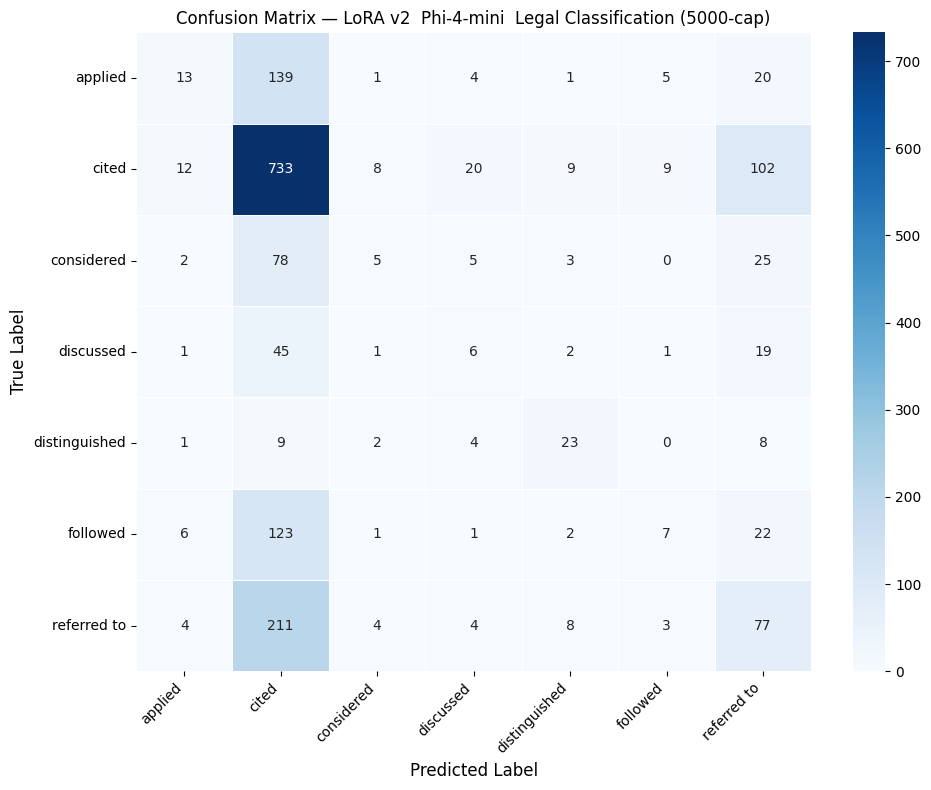

✅  Confusion matrix saved to: /content/drive/MyDrive/phi4_thesis_LoRA/metrics/confusion_matrix.png


In [ ]:
# ===========================================================================
# Confusion matrix (saved as PNG)
# ===========================================================================
cm = confusion_matrix(all_ground_truth, all_predictions, labels=LABELS_LOWER)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS_LOWER,
    yticklabels=LABELS_LOWER,
    ax=ax,
    linewidths=0.5,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title(
    "Confusion Matrix — LoRA v2  Phi-4-mini  Legal Classification (5000-cap)",
    fontsize=12,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(METRICS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"\u2705  Confusion matrix saved to: {cm_path}")

In [ ]:
# ===========================================================================
#  Save full predictions CSV (for error analysis & thesis appendix)
# ===========================================================================
results_df = pd.DataFrame({
    "case_text":        test_df[TEXT_COL].tolist(),
    "true_label":       all_ground_truth,
    "predicted_label":  all_predictions,
    "raw_model_output": all_raw_outputs,
    "correct":          [t == p for t, p in zip(all_ground_truth, all_predictions)],
})

preds_path = os.path.join(PREDICTIONS_DIR, "test_predictions.csv")
results_df.to_csv(preds_path, index=False)

print(f"\u2705  Predictions saved to: {preds_path}")
print(f"\n   Correct   : {results_df['correct'].sum()} / {len(results_df)}")
print(f"   Incorrect : {(~results_df['correct']).sum()} / {len(results_df)}")

# Quick sanity-check — show a few wrong predictions
wrong_df = results_df[~results_df["correct"]].head(5)
print("\n── Sample incorrect predictions ──")
for _, row in wrong_df.iterrows():
    print(f"  True: {row['true_label']:<15}  "
          f"Pred: {row['predicted_label']:<15}  "
          f"Raw: {repr(row['raw_model_output'][:60])}")

print("\n\U0001f389  LoRA v2 evaluation complete.")
print(f"   All outputs saved under: {PROJECT_DIR}")
print("\nNext step: run phi4_legal_lora_evaluation_v3.ipynb for the 1500-cap model,")
print("           then compare: QLoRA v2 | QLoRA v3 | LoRA v2 | LoRA v3 | Base model")

✅  Predictions saved to: /content/drive/MyDrive/phi4_thesis_LoRA/predictions/test_predictions.csv

   Correct   : 864 / 1836
   Incorrect : 972 / 1836

── Sample incorrect predictions ──
  True: discussed        Pred: referred to      Raw: 'referred to'
  True: referred to      Pred: unknown          Raw: '1) of the Act. That definition requires that the rights and '
  True: applied          Pred: referred to      Raw: 'referred to'
  True: discussed        Pred: unknown          Raw: ' Commissioner could be described as estoppel, but the princi'
  True: followed         Pred: cited            Raw: 'citedThe appellant submits that the above conclusion is part'

🎉  LoRA v2 evaluation complete.
   All outputs saved under: /content/drive/MyDrive/phi4_thesis_LoRA

Next step: run phi4_legal_lora_evaluation_v3.ipynb for the 1500-cap model,
           then compare: QLoRA v2 | QLoRA v3 | LoRA v2 | LoRA v3 | Base model


In [ ]:

from google.colab import runtime
runtime.unassign()